## Import thư viện và thiết lập

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re

# Cấu hình biểu đồ
%matplotlib inline
sns.set(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)

## Load dữ liệu từ thư mục interim

In [2]:
base_dir = os.path.dirname(os.getcwd()) 
path = os.path.join(base_dir, 'data', 'interim', 'all_sites_interim.csv')

df = pd.read_csv(path)

# In số lượng dòng/cột
print(f"Dữ liệu tổng hợp: {df.shape[0]} dòng, {df.shape[1]} cột")

# In kiểu dữ liệu của từng cột
print("\n--- Kiểu dữ liệu của các cột (dtypes) ---")
print(df.dtypes)

# In thông tin chi tiết bao gồm cả giá trị thiếu (Non-Null Count)
print("\n--- Thông tin chi tiết bộ dữ liệu (Info) ---")
df.info()

# 4. Hiển thị 5 dòng đầu tiên
df.head()

Dữ liệu tổng hợp: 10018 dòng, 10 cột

--- Kiểu dữ liệu của các cột (dtypes) ---
tieu_de           object
gia               object
dia_chi           object
dien_tich_dat    float64
phong_ngu          int64
phong_tam          int64
so_tang            int64
phap_ly           object
ngay_dang         object
source_site       object
dtype: object

--- Thông tin chi tiết bộ dữ liệu (Info) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10018 entries, 0 to 10017
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   tieu_de        10018 non-null  object 
 1   gia            10018 non-null  object 
 2   dia_chi        10018 non-null  object 
 3   dien_tich_dat  10018 non-null  float64
 4   phong_ngu      10018 non-null  int64  
 5   phong_tam      10018 non-null  int64  
 6   so_tang        10018 non-null  int64  
 7   phap_ly        10018 non-null  object 
 8   ngay_dang      10018 non-null  object 
 9   source_site 

,tieu_de,gia,dia_chi,dien_tich_dat,phong_ngu,phong_tam,so_tang,phap_ly,ngay_dang,source_site
0,Cc bán nhà hẻm 97/ Phan Đăng Lưu Quận Phú Nhuậ...,9.0,"Phố Phan Đăng Lưu, Phường 7, Quận Phú Nhuận, H...",44.5,4,5,4,Sổ hồng,2026-03-26,batdongsan
1,CÔ HOA CẦN BÁN NHÀ ĐƯỜNG LÊ HỒNG PHONG - Q10 -...,6.77,"Đường Lê Hồng Phong, Phường 10, Quận 10, Hồ Ch...",77.4,4,4,3,Sổ hồng,2026-03-28,batdongsan
2,56M (4x15). 3 TẦNG 2PN. 5.6T - GẦN CHỢ & TRƯỜN...,5.59,"Đường Huỳnh Tấn Phát, Phường Phú Thuận, Quận 7...",56.0,3,2,3,Sổ hồng,2026-03-20,batdongsan
3,"(7,8 Tỷ TL) NHÀ 3 TẦNG, 1 SẸC, GẦN SÁT MẶT TIỀ...",7.8,"Đường Bùi Thị Xuân, Phường Phạm Ngũ Lão, Quận ...",31.0,2,3,3,Sổ hồng,2026-03-29,batdongsan
4,NHÀ ĐẸP TÂN BÌNH-GẦN NHÀ GA T3-KHU VỰC HIẾM NH...,14.5,"Đường Bàu Bàng, Phường 13, Quận Tân Bình, Hồ C...",97.0,5,3,2,Sổ hồng,2026-03-30,batdongsan


## Tiến hành EDA + Preprocessing

### 1. Chuẩn hóa kiểu dữ liệu

* **Xử lý cột giá:** Thay thế dấu phẩy (,) thành dấu chấm (.) để đảm bảo Python nhận diện đúng ký tự thập phân, sau đó chuyển sang kiểu số thực (float64), tránh phát sinh giá trị thiếu (NaN)
* **Xử lý cột ngày đăng:** Sử dụng kỹ thuật (format='mixed') để xử lý sự khác biệt về cách ghi ngày tháng giữa các website

In [3]:
# Vì nhận thấy có vài ô ở cột 'gia' có dấu (,) thay vì (.)
# Thay thế dấu phẩy (,) thành dấu chấm (.) 
df['gia'] = df['gia'].str.replace(',', '.', regex=False)

# Chuyển đổi cột giá sang số (float64)
# errors='coerce' sẽ biến các giá trị không hợp lệ thành NaN
df['gia'] = pd.to_numeric(df['gia'], errors='coerce')

# huyển đổi cột ngày đăng với kỹ thuật xử lý định dạng hỗn hợp (mixed formats)
# format='mixed' giúp Pandas tự đoán định dạng cho từng dòng
# dayfirst=True ưu tiên hiểu kiểu ngày/tháng/năm của Việt Nam
df['ngay_dang'] = pd.to_datetime(df['ngay_dang'], format='mixed', dayfirst=True, errors='coerce')

# 3. Kiểm tra lại kết quả chuyển đổi
print("Kiểu dữ liệu của các cột sau khi xử lý:")
print(df.dtypes)

print("\nSố lượng giá trị lỗi (NaN) phát sinh:")
print(df[['gia', 'ngay_dang']].isnull().sum())

Kiểu dữ liệu của các cột sau khi xử lý:
tieu_de                  object
gia                     float64
dia_chi                  object
dien_tich_dat           float64
phong_ngu                 int64
phong_tam                 int64
so_tang                   int64
phap_ly                  object
ngay_dang        datetime64[ns]
source_site              object
dtype: object

Số lượng giá trị lỗi (NaN) phát sinh:
gia          0
ngay_dang    0
dtype: int64


**Kết quả:** Sau khi chuẩn hóa, bộ dữ liệu không còn giá trị thiếu, sẵn sàng cho các bước phân tích khám phá (EDA) tiếp theo.

### 2. EDA để xác định các điểm Outliers

Sau khi chuẩn hóa dữ liệu, bước tiếp theo là xác định các giá trị bất thường (Outliers). Trong bài toán bất động sản, Outliers thường xuất hiện ở các trường hợp:
* Tin đăng ảo với giá trị cực thấp hoặc diện tích cực lớn.
* Các bất động sản đặc biệt (siêu biệt thự, tòa nhà văn phòng) có giá hàng nghìn tỷ, không đại diện cho mặt bằng chung của thị trường.

Nhóm sử dụng biểu đồ **Boxplot** để trực quan hóa. Các điểm nằm ngoài rìa của Boxplot chính là các ứng viên Outlier có khả năng làm sai lệch đường hồi quy của mô hình Linear Regression.

**Mục tiêu:** Xác định ngưỡng giá trị mà tại đó các bất động sản không còn mang tính đại diện cho thị trường nhà ở dân dụng (ví dụ: diện tích quá lớn hoặc số phòng quá nhiều).

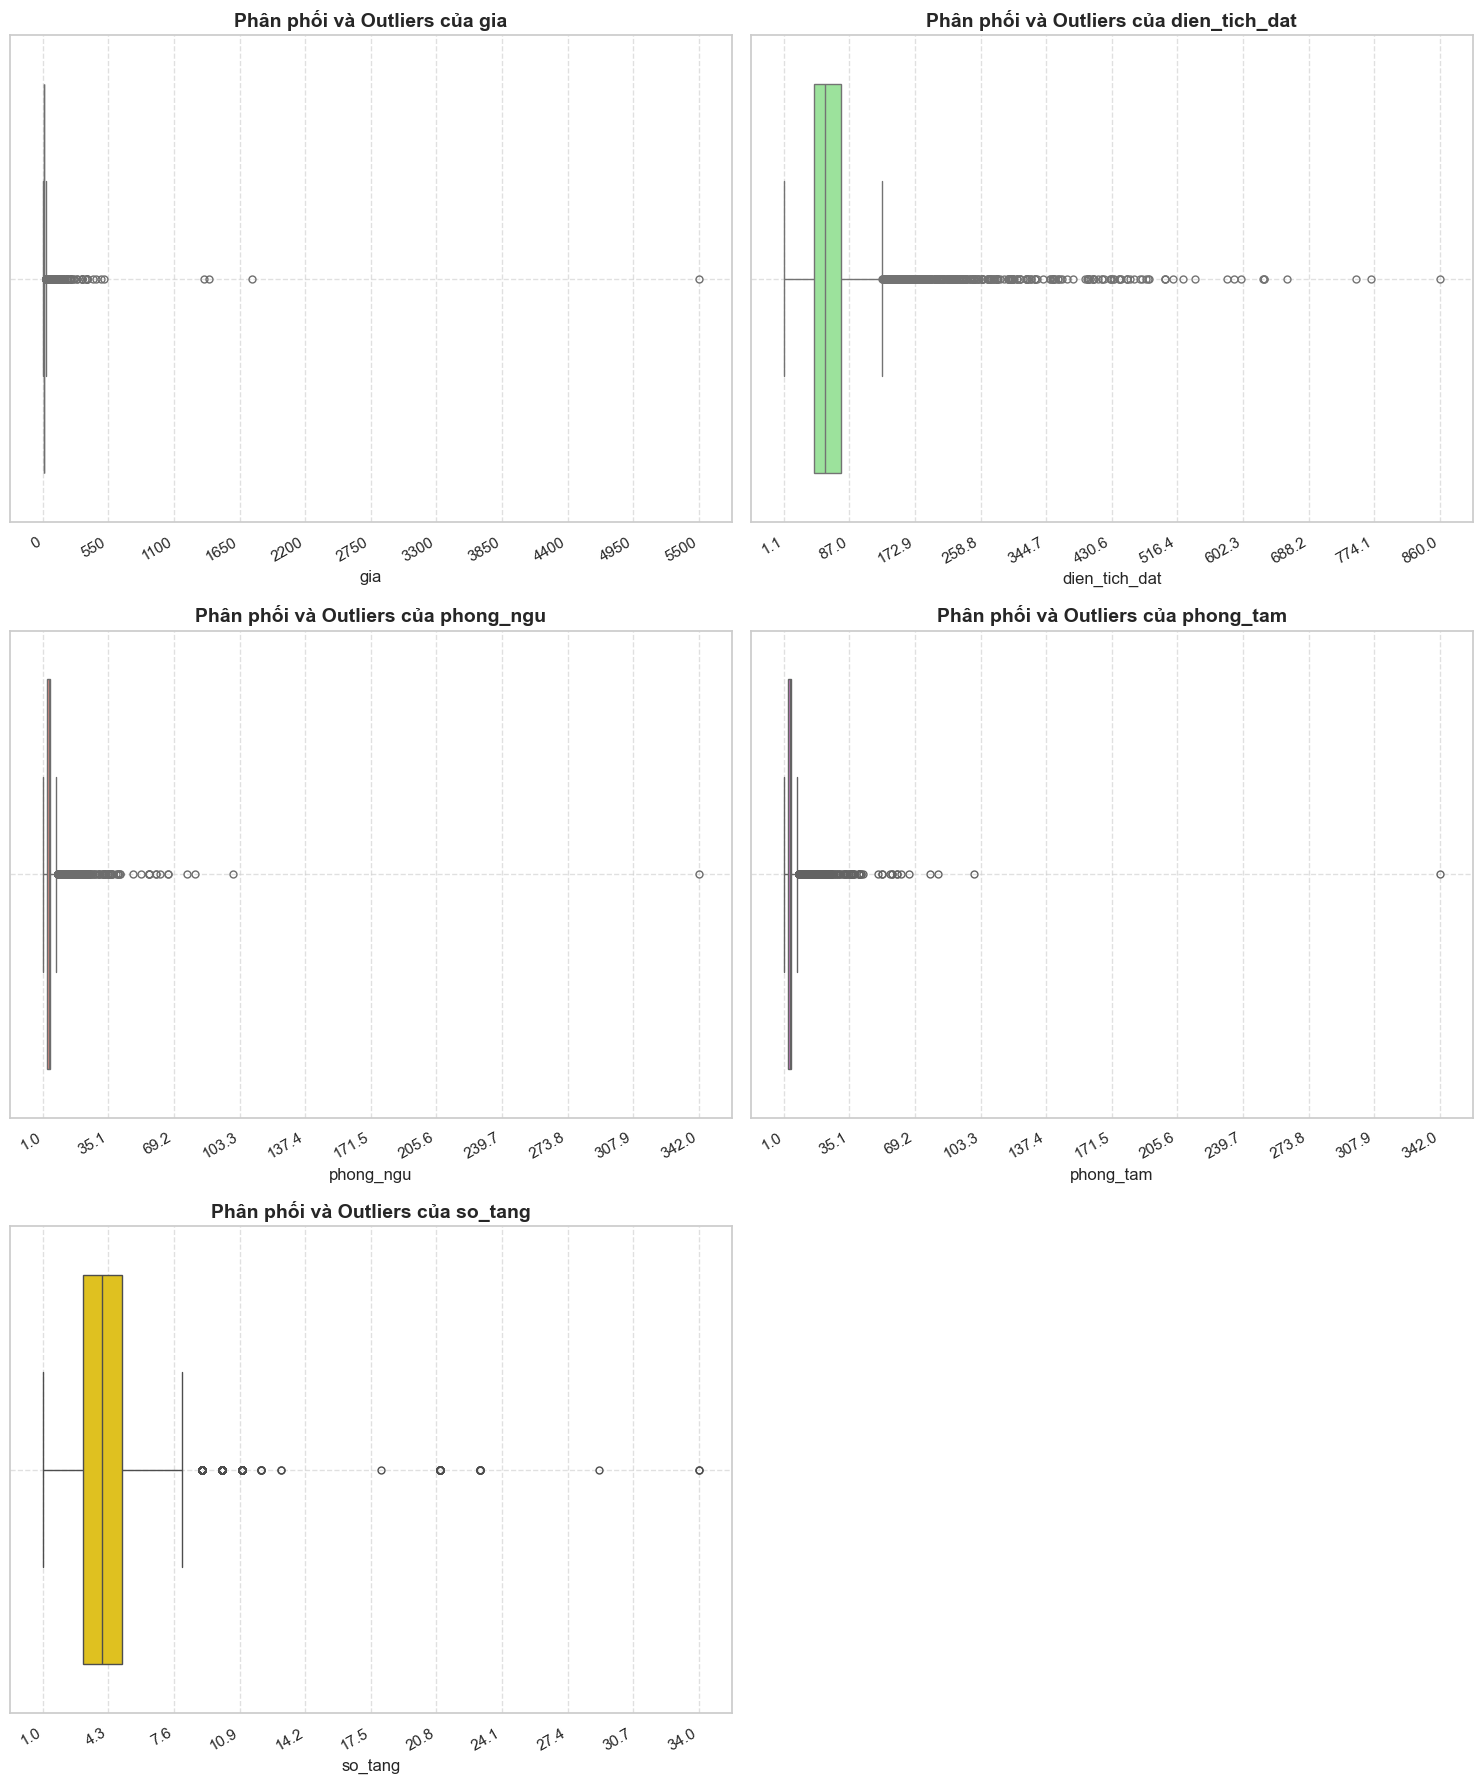

Thống kê các mốc phân vị (Percentiles) để xác định ngưỡng cắt:


,0.50,0.75,0.90,0.95,0.99
gia,8.0,13.0,24.53,36.0,95.0
dien_tich_dat,55.0,76.0,105.00,145.0,300.0
phong_ngu,4.0,5.0,6.00,8.0,19.0
phong_tam,4.0,5.0,6.00,9.0,19.0
so_tang,4.0,5.0,7.00,8.0,10.0


In [4]:
features = ['gia', 'dien_tich_dat', 'phong_ngu', 'phong_tam', 'so_tang']
colors = ['skyblue', 'lightgreen', 'salmon', 'orchid', 'gold']

fig, axes = plt.subplots(3, 2, figsize=(15, 18))
axes = axes.flatten() # Trải phẳng mảng axes để lặp dễ hơn

for i, col in enumerate(features):
    sns.boxplot(x=df[col], ax=axes[i], color=colors[i], fliersize=5)
    
    # Thiết lập tiêu đề và lưới
    axes[i].set_title(f'Phân phối và Outliers của {col}', fontsize=14, fontweight='bold')
    axes[i].grid(True, linestyle='--', alpha=0.6)
    
    # Lấy giá trị min, max để chia mốc
    vmin = df[col].min()
    vmax = df[col].max()
    # Chia trục X thành 10 khoảng bằng nhau
    axes[i].set_xticks(np.linspace(vmin, vmax, 11))
    # Xoay nhãn nếu giá trị quá dài (như cột giá tỷ)
    plt.setp(axes[i].get_xticklabels(), rotation=30, horizontalalignment='right')

axes[5].axis('off')

plt.tight_layout()
plt.show()

print("Thống kê các mốc phân vị (Percentiles) để xác định ngưỡng cắt:")
percentiles = df[features].quantile([0.5, 0.75, 0.9, 0.95, 0.99]).T
display(percentiles)

### Xử lý các điểm Outliers

Dựa trên phân tích Boxplot và bảng phân vị (Percentiles), nhóm nhận thấy sự tồn tại của các giá trị cực đoan không mang tính đại diện cho phân khúc nhà ở dân dụng:
* **Giá:** 99% dữ liệu nằm dưới 95 tỷ, nhưng có giá trị lên tới 5500 tỷ.
* **Diện tích:** 99% dưới 300m2, cực đại là 860m2.
* **Cấu trúc:** Có những bản ghi ghi nhận hơn 300 phòng ngủ/phòng tắm, đây rõ ràng là lỗi nhập liệu hoặc các tòa nhà đặc biệt.

**Quyết định:** Nhóm thực hiện lọc dữ liệu xoay quanh Percentile 99% cho các biến quan trọng để đảm bảo mô hình tập trung vào phân khúc nhà ở phổ thông, giúp tăng độ chính xác và tính ổn định.

In [5]:
# nới lỏng một chút so với mốc 99% để giữ tối đa dữ liệu hợp lý
df_clean = df[
    (df['gia'] <= 150) &           # Lọc nhà dưới 150 tỷ (vẫn giữ được các biệt thự hạng sang)
    (df['dien_tich_dat'] <= 400) & # Lọc diện tích dưới 400m2
    (df['phong_ngu'] <= 15) &      # Lọc nhà dưới 15 phòng ngủ
    (df['phong_tam'] <= 15) &      # Lọc nhà dưới 15 phòng tắm
    (df['so_tang'] <= 10)          # Lọc nhà dưới 10 tầng
].copy()

print(f"Số lượng dòng trước khi lọc: {len(df)}")
print(f"Số lượng dòng sau khi lọc: {len(df_clean)}")
print(f"Đã loại bỏ {len(df) - len(df_clean)} dòng Outliers (~{((len(df) - len(df_clean))/len(df))*100:.2f}%)")

Số lượng dòng trước khi lọc: 10018
Số lượng dòng sau khi lọc: 9734
Đã loại bỏ 284 dòng Outliers (~2.83%)


### 4. Kiểm tra phân phối sau khi làm sạch (Diagnostic Plot)

Sau khi loại bỏ các giá trị cực đoan (Outliers), ta cần đánh giá lại hình dạng của biến mục tiêu thông qua biểu đồ Histogram và Q-Q Plot. Bước này giúp ta:
* Kiểm tra xem độ lệch (Skewness) có đạt mức chấp nhận được chưa.
* Đánh giá mức độ tiệm cận phân phối chuẩn thông qua đường thẳng tham chiếu trong Q-Q Plot.

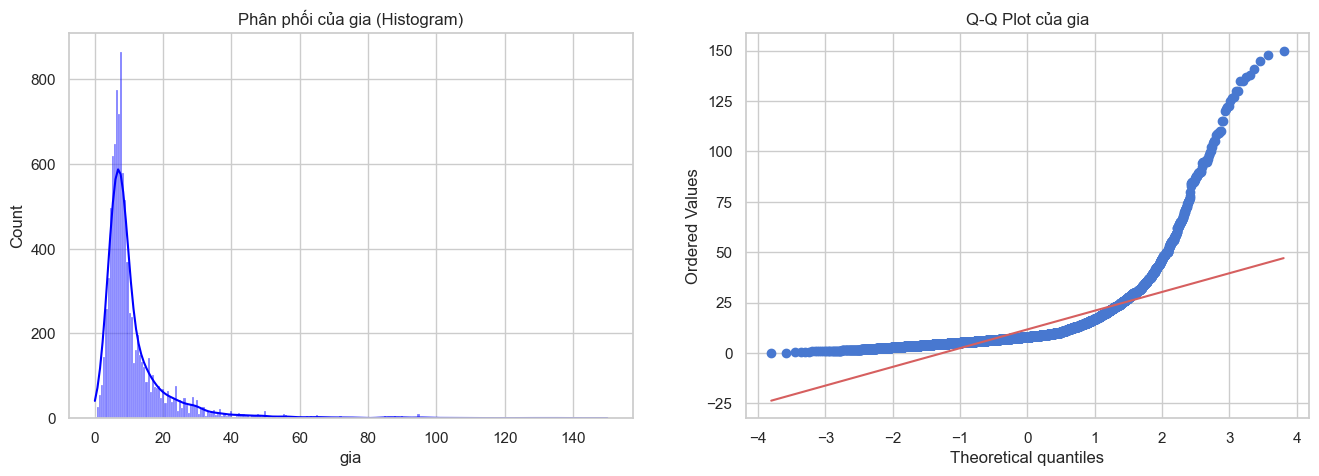

Độ lệch (Skewness) của gia: 4.62


In [6]:
from scipy import stats

# Định nghĩa hàm chẩn đoán phân phối
def diagnostic_plot(df, col):
    plt.figure(figsize=(16, 5))

    # Biểu đồ Histogram kèm đường KDE
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], kde=True, color='blue')
    plt.title(f'Phân phối của {col} (Histogram)')

    # Biểu đồ Q-Q plot để kiểm tra tính chuẩn hóa (Normality)
    plt.subplot(1, 2, 2)
    stats.probplot(df[col], dist="norm", plot=plt)
    plt.title(f'Q-Q Plot của {col}')

    plt.show()
    
    print(f"Độ lệch (Skewness) của {col}: {df[col].skew():.2f}")

diagnostic_plot(df_clean, 'gia')

Không chỉ biến mục tiêu, các biến đầu vào như `dien_tich_dat` cũng cần được kiểm tra phân phối vì nó có phạm vi giá trị lớn. Nếu nó bị lệch quá nặng, nó có thể gây ra hiện tượng không tuyến tính hoặc tạo ra các điểm có sức ảnh hưởng lớn làm sai lệch mô hình. 

Các biến đếm số lượng (phòng, tầng) có phạm vi biến thiên hẹp. Việc lấy Log sẽ không mang lại nhiều lợi ích về mặt thống kê như các biến có phạm vi rộng (`gia`, `dien_tich_dat`)

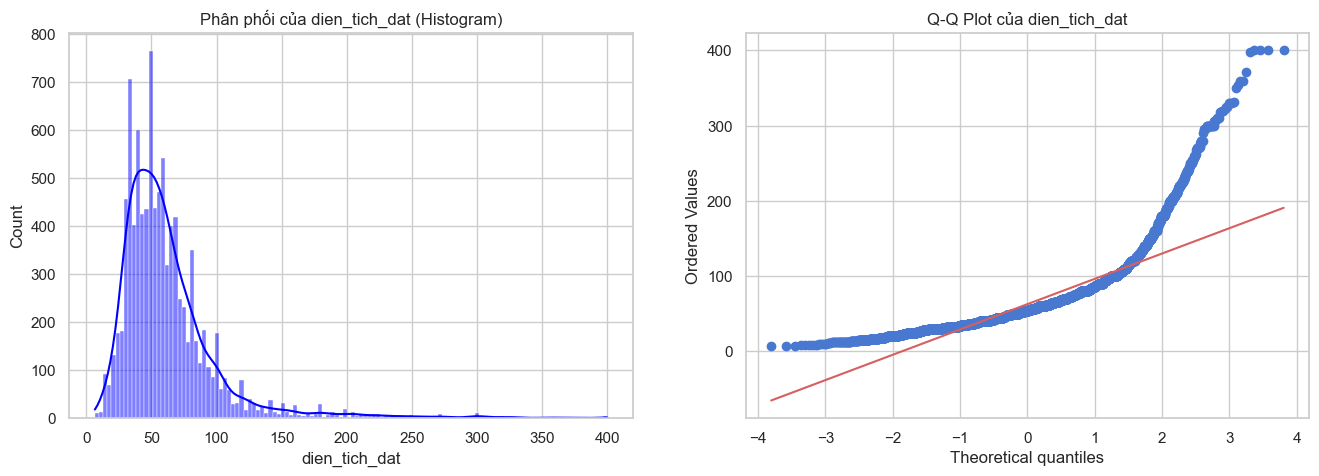

Độ lệch (Skewness) của dien_tich_dat: 2.99


In [7]:
diagnostic_plot(df_clean, 'dien_tich_dat')

### Biến đổi Logarit (Feature Transformation)

Dựa trên kết quả EDA, nhóm quyết định thực hiện phép biến đổi Logarit cho hai đặc trưng:
1. **Biến mục tiêu (gia):** Để ổn định phương sai sai số và đưa về phân phối chuẩn.
2. **Biến diện tích (dien_tich_dat):** Để cân nhắc nếu muốn nắn thẳng mối quan hệ tuyến tính với giá nhà.

--- KIỂM TRA PHÂN PHỐI SAU KHI LOG-TRANSFORM ---


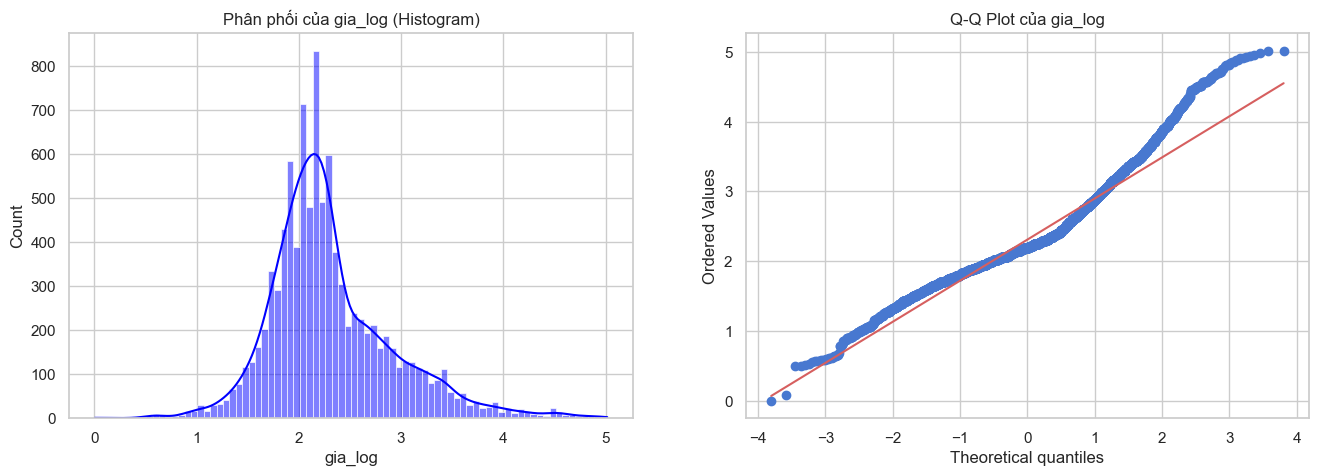

Độ lệch (Skewness) của gia_log: 0.98


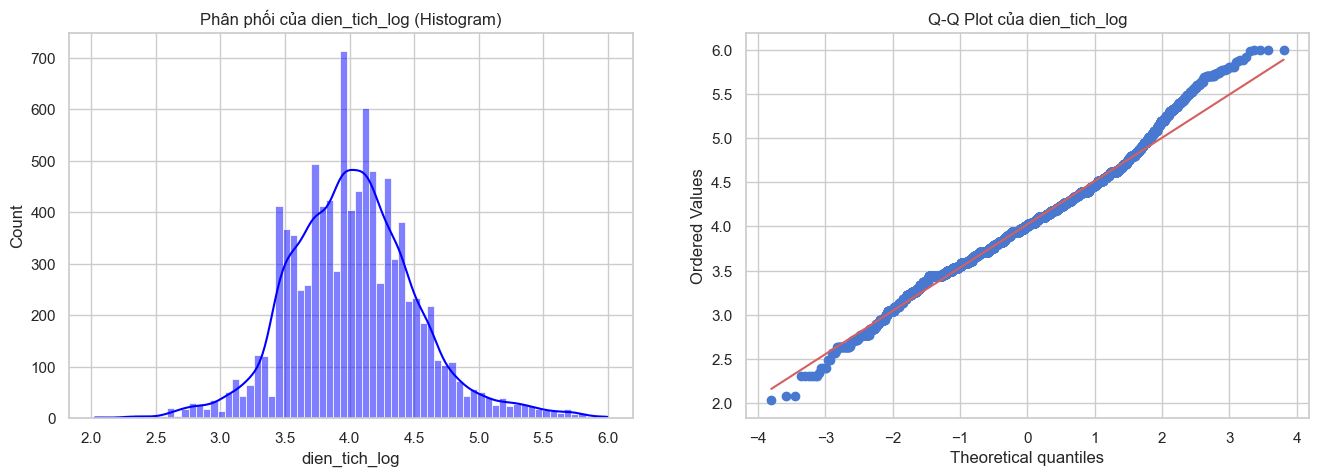

Độ lệch (Skewness) của dien_tich_log: 0.32


In [8]:
# Thực hiện Log-transform cho Giá và Diện tích
# log1p giúp tránh lỗi nếu giá trị bằng 0 (ln(1+x))
df_clean['gia_log'] = np.log1p(df_clean['gia'])
df_clean['dien_tich_log'] = np.log1p(df_clean['dien_tich_dat'])

# 2. Kiểm tra lại phân phối của Giá sau khi lấy Log
print("--- KIỂM TRA PHÂN PHỐI SAU KHI LOG-TRANSFORM ---")
diagnostic_plot(df_clean, 'gia_log')

# 3. Kiểm tra lại phân phối của Diện tích sau khi lấy Log
diagnostic_plot(df_clean, 'dien_tich_log')

Sau khi thực hiện biến đổi Logarit, hình dạng phân phối của dữ liệu đã cải thiện rõ rệt:

- **gia_log:** Skewness giảm mạnh từ 4.62 xuống còn 0.98, đưa phân phối về gần mức chuẩn.
- **dien_tich_log:** Đạt kết quả lý tưởng với Skewness = 0.32, đường Q-Q Plot gần như là một đường thẳng.

**Kết luận:** Phép biến đổi giúp ổn định phương sai và nắn thẳng mối quan hệ giữa diện tích và giá. Có thể cân nhắc sử dụng `dien_tich_log` để tìm ra mô hình tốt nhất.

### 5. Trích xuất đặc trưng `dia_chi`
Vị trí là yếu tố rất quan trọng quyết định giá trị bất động sản. Nhóm thực hiện trích xuất thông tin cấp Quận/Huyện và Thành phố từ cột địa chỉ. Việc này giúp giảm bớt độ nhiễu của dữ liệu văn bản và tạo ra các nhóm vị trí có ý nghĩa thống kê:

- **Thành phố (city)**: Để mô hình nắm bắt được mặt bằng giá chung của từng vùng thị trường.
- **Quận/Huyện (district)**: Để mô hình đánh giá tác động của vị trí cụ thể trong nội thành.

In [9]:
import re

def extract_location_info(address):
    if pd.isna(address): 
        return "Khác", "Khác"
    
    address = str(address)
    
    # Trích xuất Thành phố
    city = "Khác"
    if any(keyword in address for keyword in ["Hồ Chí Minh", "TP.HCM", "TP HCM", "HCM"]):
        city = "TP.HCM"
    elif "Hà Nội" in address:
        city = "Hà Nội"
        
    # 2. Trích xuất Quận/Huyện bằng Regex
    district = "Khác"
    # Tìm các cụm từ Quận/Huyện/Thị xã/Thành phố (cấp quận)
    match = re.search(r'(Quận\s+\d+|Quận\s+[\w\s]+|Huyện\s+[\w\s]+|Thành phố\s+[\w\s]+|Thị xã\s+[\w\s]+)', address)
    if match:
        district_raw = match.group(1).strip()
        # Chuẩn hóa: Chỉ lấy 3 từ đầu để tránh dính sang tên Phường
        district = " ".join(district_raw.split()[:3])
    
    return district, city

# Áp dụng hàm để tạo 2 cột mới
df_clean[['quan', 'thanh_pho']] = df_clean['dia_chi'].apply(lambda x: pd.Series(extract_location_info(x)))

# Kiểm tra phân phối theo Thành phố
print("--- PHÂN BỔ DỮ LIỆU THEO THÀNH PHỐ ---")
print(df_clean['thanh_pho'].value_counts())

print("--- PHÂN BỔ DỮ LIỆU THEO Quận ---")
print(df_clean['quan'].value_counts())

# Kiểm tra một vài dòng dữ liệu vị trí
print("\n--- MẪU DỮ LIỆU VỊ TRÍ ĐÃ TRÍCH XUẤT ---")
display(df_clean[['dia_chi', 'quan', 'thanh_pho']].head(10))

--- PHÂN BỔ DỮ LIỆU THEO THÀNH PHỐ ---
thanh_pho
TP.HCM    6574
Hà Nội    3146
Khác        14
Name: count, dtype: int64
--- PHÂN BỔ DỮ LIỆU THEO Quận ---
quan
Khác                615
Quận Bình Tân       513
Quận 12             501
Quận 7              499
Quận Tân Phú        477
Quận 8              468
Quận Phú Nhuận      448
Quận Tân Bình       441
Quận Hà Đông        438
Quận Gò Vấp         435
Quận 10             434
Quận 6              427
Quận 3              358
Quận 1              323
Quận Đống Đa        310
Quận 2              307
Quận Thanh Xuân     291
Quận Hoàng Mai      286
Quận 11             272
Quận 4              271
Quận Long Biên      220
Quận Cầu Giấy       219
Quận Hai Bà         178
Quận 5              171
Quận Nam Từ         134
Quận 9              130
Huyện Hoài Đức      112
Quận Ba Đình        100
Quận Bình Thạnh      91
Quận Tây Hồ          65
Quận Bắc Từ          61
Huyện Thanh Trì      45
Quận Hoàn Kiếm       31
Huyện Gia Lâm        18
Huyện Đan Phượng     12
H

,dia_chi,quan,thanh_pho
0,"Phố Phan Đăng Lưu, Phường 7, Quận Phú Nhuận, H...",Quận Phú Nhuận,TP.HCM
1,"Đường Lê Hồng Phong, Phường 10, Quận 10, Hồ Ch...",Quận 10,TP.HCM
2,"Đường Huỳnh Tấn Phát, Phường Phú Thuận, Quận 7...",Quận 7,TP.HCM
3,"Đường Bùi Thị Xuân, Phường Phạm Ngũ Lão, Quận ...",Quận 1,TP.HCM
4,"Đường Bàu Bàng, Phường 13, Quận Tân Bình, Hồ C...",Quận Tân Bình,TP.HCM
5,"1/ , Đường Đông Bắc, Phường Tân Chánh Hiệp, Qu...",Quận 12,TP.HCM
6,"Đường Cao Lỗ, Phường 4, Quận 8, Hồ Chí Minh",Quận 8,TP.HCM
7,"Đường Âu Cơ, Phường 14, Quận Tân Bình, Hồ Chí ...",Quận Tân Bình,TP.HCM
8,"Phường Phú Thuận, Quận 7, Hồ Chí Minh",Quận 7,TP.HCM
9,"Đường Cây Trâm, Phường 9, Quận Gò Vấp, Hồ Chí ...",Quận Gò Vấp,TP.HCM


**Nhận xét:**
- Vì có nhiều Quận/Huyện bị cắt xén chữ, ta thực hiện sửa đổi cho đúng tên.
- Đồng thời, có nhiều mẫu có giá trị `thanh_pho` và `quan` là 'Khác' do bước nhập địa chỉ bị sai sót hoặc thiếu chữ. Nhưng nhận thấy số lượng không quá lớn, nếu xóa thì vẫn còn hơn **9100** mẫu, nhóm quyết định loại bỏ chúng để làm sạch đữ liệu 100%.

In [10]:
# Định nghĩa từ điển ánh xạ (Mapping) để sửa các tên bị cắt thiếu
district_fixes = {
    'Quận Hai Bà': 'Quận Hai Bà Trưng',
    'Quận Nam Từ': 'Quận Nam Từ Liêm',
    'Quận Bắc Từ': 'Quận Bắc Từ Liêm',
    'Thị xã Sơn': 'Thị xã Sơn Tây',
    'Thành phố Giao': 'Thành phố Giao Lưu'
}

# Thực hiện thay thế trong cột 'quan'
df_clean['quan'] = df_clean['quan'].replace(district_fixes)

# 3. Loại bỏ các dòng "Khác" như đã thống nhất để làm sạch 100% dữ liệu vị trí
df_final = df_clean[
    (df_clean['thanh_pho'] != 'Khác') & 
    (df_clean['quan'] != 'Khác')
].copy()

# 4. Kiểm tra lại danh sách cuối cùng để đảm bảo mọi thứ đã chuẩn
print("--- DANH SÁCH QUẬN/HUYỆN ĐÃ CHUẨN HÓA ---")
print(df_final['quan'].value_counts())

print(f"\nTổng số mẫu dữ liệu sạch cuối cùng: {len(df_final)}")

--- DANH SÁCH QUẬN/HUYỆN ĐÃ CHUẨN HÓA ---
quan
Quận Bình Tân         513
Quận 12               501
Quận 7                499
Quận Tân Phú          477
Quận 8                468
Quận Phú Nhuận        448
Quận Tân Bình         441
Quận Hà Đông          437
Quận Gò Vấp           435
Quận 10               434
Quận 6                427
Quận 3                358
Quận 1                323
Quận Đống Đa          309
Quận 2                307
Quận Thanh Xuân       291
Quận Hoàng Mai        286
Quận 11               272
Quận 4                271
Quận Long Biên        219
Quận Cầu Giấy         219
Quận Hai Bà Trưng     178
Quận 5                171
Quận Nam Từ Liêm      134
Quận 9                130
Huyện Hoài Đức        112
Quận Ba Đình          100
Quận Bình Thạnh        91
Quận Tây Hồ            65
Quận Bắc Từ Liêm       61
Huyện Thanh Trì        45
Quận Hoàn Kiếm         31
Huyện Gia Lâm          18
Huyện Đan Phượng       12
Huyện Đông Anh          8
Huyện Chương Mỹ         7
Huyện Mê Linh    

**Nhận xét:** 
- Có nhiều quận chỉ mang số lượng rất ít mẫu trong dataset. Điều này có thể gây ra hiện tượng Overfitting. Nếu một quận chỉ có 1 căn nhà, mô hình Linear Regression sẽ gán toàn bộ đặc điểm của căn nhà đó cho cả quận.
- Nên thay vì xóa (đã xóa 629 dòng rồi, không nên xóa thêm), nhóm đặt một ngưỡng (threshold = 20). Quận nào có ít hơn ngưỡng này sẽ được đổi tên thành "Quận/Huyện khác".

In [11]:
# Đếm số lượng mẫu của từng quận
quan_counts = df_final['quan'].value_counts()

# Xác định các quận "hiếm" (ví dụ dưới 20 mẫu)
threshold = 20
rare_quans = quan_counts[quan_counts < threshold].index

# Gom các quận này vào nhóm "Quận/Huyện khác"
df_final['quan'] = df_final['quan'].apply(lambda x: 'Quận/Huyện khác' if x in rare_quans else x)

print(f"Số lượng quận sau khi gom nhóm: {df_final['quan'].nunique()}")
print("\nDanh sách các quận sau khi xử lý:")
print(df_final['quan'].value_counts())

Số lượng quận sau khi gom nhóm: 33

Danh sách các quận sau khi xử lý:
quan
Quận Bình Tân        513
Quận 12              501
Quận 7               499
Quận Tân Phú         477
Quận 8               468
Quận Phú Nhuận       448
Quận Tân Bình        441
Quận Hà Đông         437
Quận Gò Vấp          435
Quận 10              434
Quận 6               427
Quận 3               358
Quận 1               323
Quận Đống Đa         309
Quận 2               307
Quận Thanh Xuân      291
Quận Hoàng Mai       286
Quận 11              272
Quận 4               271
Quận Long Biên       219
Quận Cầu Giấy        219
Quận Hai Bà Trưng    178
Quận 5               171
Quận Nam Từ Liêm     134
Quận 9               130
Huyện Hoài Đức       112
Quận Ba Đình         100
Quận Bình Thạnh       91
Quận Tây Hồ           65
Quận/Huyện khác       63
Quận Bắc Từ Liêm      61
Huyện Thanh Trì       45
Quận Hoàn Kiếm        31
Name: count, dtype: int64


### 6. Tối ưu hóa biến phân loại `phap_ly`

In [12]:
legal_counts = df_final['phap_ly'].value_counts()
print("Phân bổ cột pháp lý:")
print(legal_counts)

Phân bổ cột pháp lý:
phap_ly
Sổ hồng                   8844
Giấy tờ không xác định     248
Sổ đỏ                       24
Name: count, dtype: int64


Qua thống kê, nhóm nhận thấy sự mất cân bằng dữ liệu nghiêm trọng ở cột pháp lý: hạng mục "Sổ đỏ" chỉ chiếm 24 mẫu (0.2%). Trong thực tế, "Sổ đỏ" và "Sổ hồng" có giá trị kinh tế và tác động đến giá bất động sản tương đương nhau.

Vì thế, nhóm thực hiện gộp hai hạng mục này thành một nhóm chung mang tên **"Đã có sổ"**. Việc này giúp:
* Loại bỏ sự thưa thớt dữ liệu (Data Sparsity).
* Tránh hiện tượng hệ số hồi quy bị nhiễu hoặc quá khớp (Overfitting).
* Giúp mô hình so sánh rõ ràng giữa hai trạng thái: **Đã có pháp lý rõ ràng** và **Giấy tờ chưa xác định**.

In [13]:
# Gộp "Sổ đỏ" và "Sổ hồng" thành "Đã có sổ"
df_final['phap_ly'] = df_final['phap_ly'].replace('Sổ đỏ', 'Sổ hồng')
df_final['phap_ly'] = df_final['phap_ly'].replace('Sổ hồng', 'Đã có sổ')

# Kiểm tra lại phân bổ sau khi gộp
print("Phân bổ cột pháp lý sau khi tối ưu:")
print(df_final['phap_ly'].value_counts())

Phân bổ cột pháp lý sau khi tối ưu:
phap_ly
Đã có sổ                  8868
Giấy tờ không xác định     248
Name: count, dtype: int64


### 7. Phân tích Ma trận tương quan (Correlation Matrix)

Để lựa chọn các đặc trưng (features) phù hợp cho mô hình, nhóm thực hiện phân tích tương quan giữa các biến số. Bước này đóng vai trò quan trọng trong việc xây dựng chiến lược cho 5 mô hình khác nhau của các thành viên:

* **Xác định biến quan trọng:** Tìm ra đặc trưng nào có mối liên hệ mật thiết nhất với biến mục tiêu (`gia_log` hay `gia`).
* **Kiểm tra Đa cộng tuyến (Multicollinearity):** Đánh giá xem các biến đầu vào (ví dụ: số phòng ngủ và số phòng tắm) có tương quan quá mức với nhau hay không. Nếu chỉ số tương quan giữa hai biến độc lập > 0.8, việc đưa cả hai vào cùng một mô hình có thể làm mất ổn định các hệ số hồi quy.
* **Cơ sở thiết kế Model:** Kết quả từ ma trận này giúp các thành viên quyết định nên giữ lại đặc trưng nào hoặc thực hiện các biến đổi nâng cao (như biến tương tác) để tối ưu hóa chỉ số $R^2$.

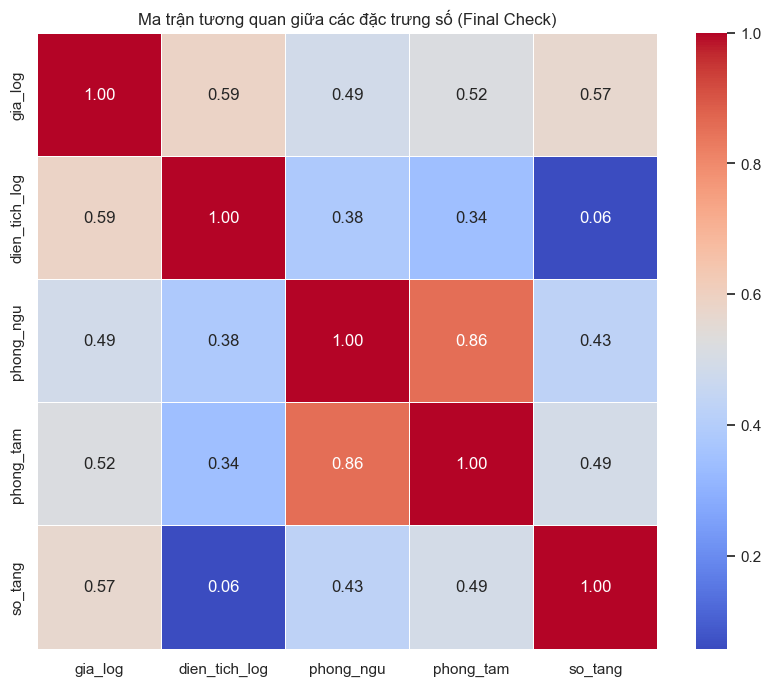

In [14]:
# 1. Tính toán ma trận tương quan giữa các biến số
# Lưu ý: Chỉ tính trên các cột số
numeric_cols = ['gia_log', 'dien_tich_log', 'phong_ngu', 'phong_tam', 'so_tang']
corr_matrix = df_final[numeric_cols].corr()

# 2. Vẽ Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Ma trận tương quan giữa các đặc trưng số (Final Check)")
plt.show()

#### Nhận xét:

1. **Mối quan hệ với biến mục tiêu (`gia_log`):**
   - **Diện tích (`dien_tich_log`)** và **Số tầng (`so_tang`)** thể hiện tương quan dương mạnh nhất với giá nhà (lần lượt là **0.59** và **0.57**). Đây sẽ là hai biến dự báo chủ chốt trong các mô hình hồi quy.
   - Các biến cấu trúc như số phòng tắm (**0.52**) và số phòng ngủ (**0.49**) cũng có tác động tích cực đến giá trị bất động sản.

2. **Hiện tượng Đa cộng tuyến (Multicollinearity):**
   - Có sự tương quan rất cao (**0.86**) giữa **số phòng ngủ (`phong_ngu`)** và **số phòng tắm (`phong_tam`)**. 
   - *Lưu ý:* Việc đưa cả hai biến này vào cùng một mô hình có thể gây ra hiện tượng đa cộng tuyến, làm sai lệch hệ số hồi quy. Cần cân nhắc chỉ chọn một trong hai hoặc thực hiện kết hợp biến.

3. **Tính độc lập của dữ liệu:**
   - Chỉ số tương quan thấp giữa số tầng và diện tích (**0.06**) cho thấy sự đa dạng của bộ dữ liệu (có cả nhà diện tích lớn ít tầng và nhà cao tầng trên diện tích nhỏ), giúp mô hình nắm bắt được nhiều phân khúc nhà ở khác nhau.

### 8. Kiểm tra tính tuyến tính

Để đánh giá mức độ phù hợp của mô hình hồi quy tuyến tính, nhóm thực hiện so sánh mối quan hệ giữa **Diện tích** và **Giá** trên hai thang đo: Dữ liệu gốc và Dữ liệu biến đổi Logarit.

Mục tiêu của bước này là:
* **Kiểm tra giả định tuyến tính:** Xác định xem dữ liệu ở thang đo nào tạo thành một dải thẳng đồng nhất hơn.
* **Đánh giá phương sai:** Kiểm tra xem sai số có ổn định trên toàn dải giá trị hay không.

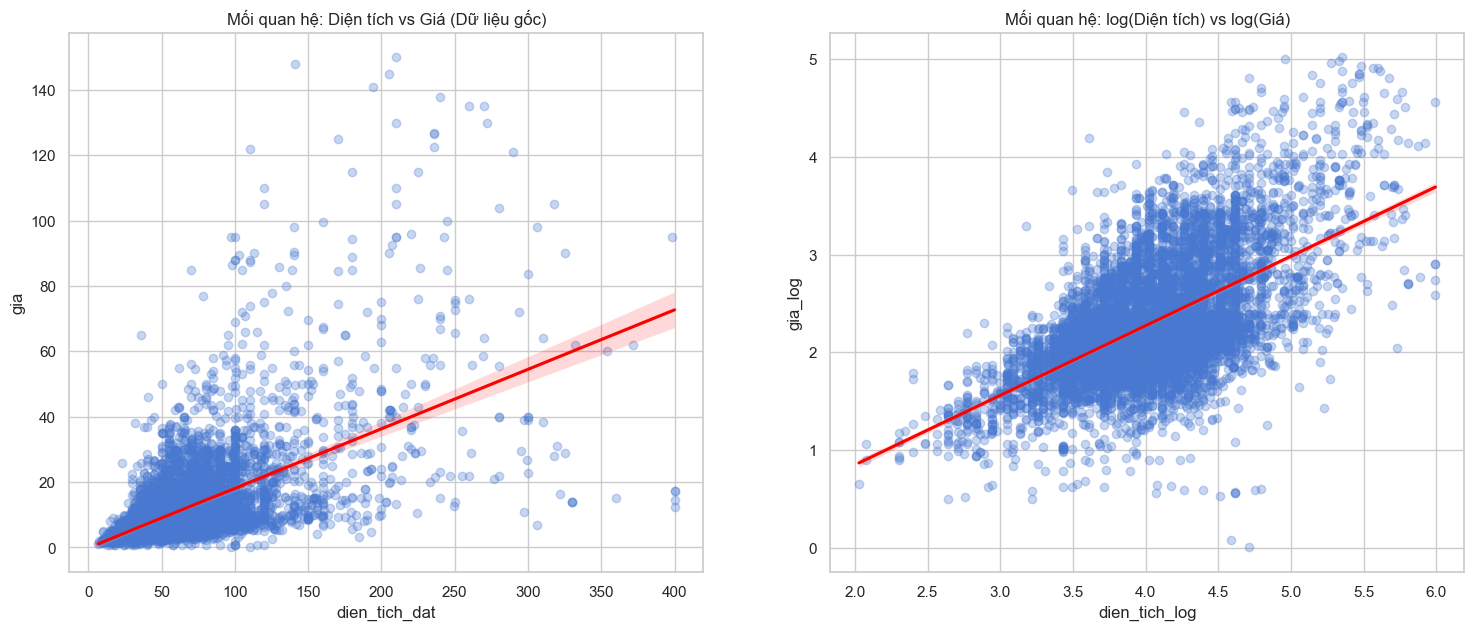

In [15]:
# Vẽ biểu đồ Scatter Plot kèm đường hồi quy (Regression Line)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# So sánh Diện tích gốc vs Giá gốc
sns.regplot(data=df_final, x='dien_tich_dat', y='gia', ax=axes[0], 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
axes[0].set_title("Mối quan hệ: Diện tích vs Giá (Dữ liệu gốc)")

# So sánh Diện tích Log vs Giá Log
sns.regplot(data=df_final, x='dien_tich_log', y='gia_log', ax=axes[1], 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
axes[1].set_title("Mối quan hệ: log(Diện tích) vs log(Giá)")

plt.show()

### Nhận xét:

1. **Dữ liệu gốc (Biểu đồ trái):** Các điểm dữ liệu có xu hướng lan rộng như hình cái phễu khi diện tích tăng lên (phương sai thay đổi nhiều). Điều này gây khó khăn cho mô hình trong việc dự báo chính xác ở phân khúc giá cao.
2. **Dữ liệu Log-Log (Biểu đồ phải):** Sau khi lấy Logarit cho cả hai trục, các điểm dữ liệu tạo thành một dải thẳng bám sát đường hồi quy hơn (màu đỏ). 

**Kết luận:** Biến đổi Logarit đã nắn thẳng mối quan hệ giữa Diện tích và Giá, đồng thời giúp ổn định phương sai của sai số.

### 9. Phân tích tác động của các yếu tố định tính (Categorical Analysis)

Để đánh giá tầm quan trọng của các yếu tố phi định tính, nhóm thực hiện phân tích phân bổ giá nhà (thang đo Log) theo **Thành phố** và **Pháp lý**:
* **Thành phố:** So sánh mặt bằng giá giữa hai thị trường lớn nhất cả nước là Hà Nội và TP.HCM.
* **Pháp lý:** Kiểm tra sự chênh lệch giá trị giữa nhóm bất động sản đã hoàn thiện giấy tờ và nhóm chưa rõ ràng về pháp lý.

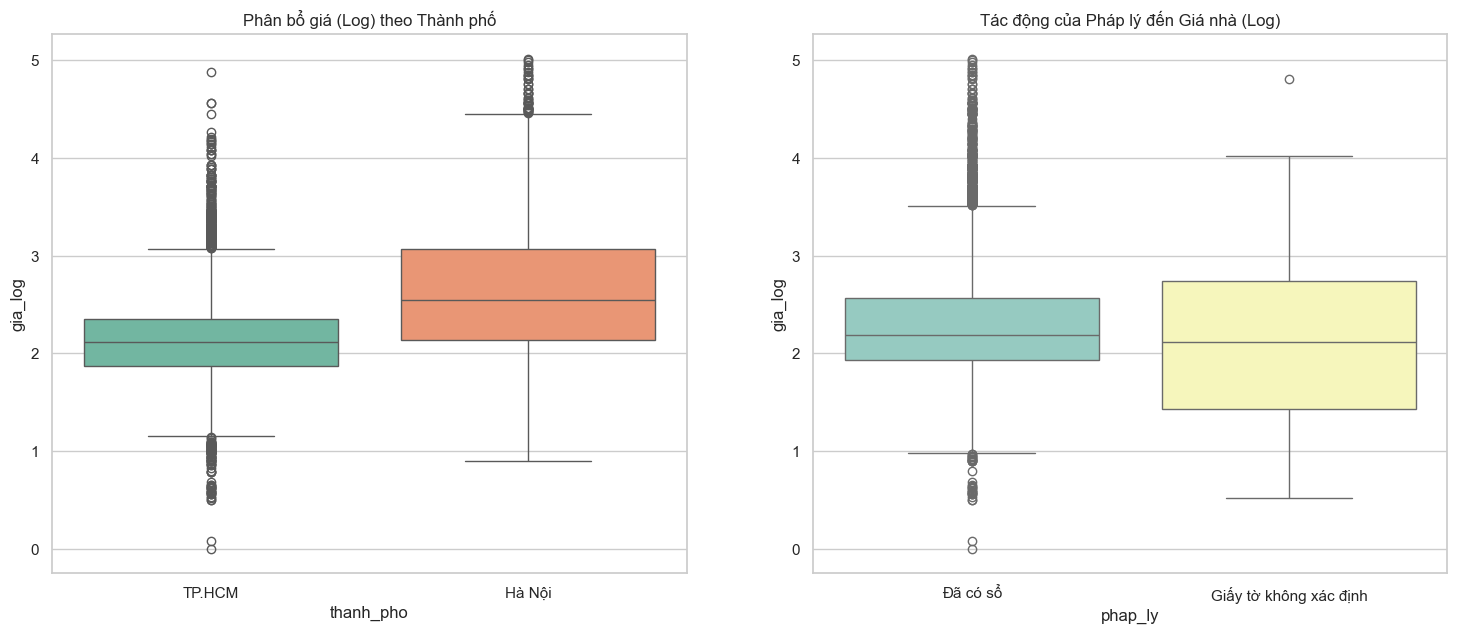

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# So sánh mặt bằng giá giữa Hà Nội và TP.HCM
sns.boxplot(data=df_final, x='thanh_pho', y='gia_log', ax=axes[0], palette='Set2', hue='thanh_pho', legend=False)
axes[0].set_title("Phân bổ giá (Log) theo Thành phố")

# Tác động của Pháp lý đến giá nhà
sns.boxplot(data=df_final, x='phap_ly', y='gia_log', ax=axes[1], palette='Set3', hue='phap_ly', legend=False)
axes[1].set_title("Tác động của Pháp lý đến Giá nhà (Log)")

plt.show()

### Nhận xét:

1. **Về Thành phố (Biểu đồ trái):** Mặt bằng giá nhà tại **Hà Nội** (trên thang đo Log) có xu hướng cao hơn rõ rệt so với **TP.HCM** trong bộ dữ liệu này. Đây là một đặc trưng quan trọng mà nhóm cần cân nhắc đưa vào mô hình để tăng độ chính xác dự báo.
2. **Về Pháp lý (Biểu đồ phải):** Các bất động sản **"Đã có sổ"** có dải giá ổn định và tập trung hơn. Ngược lại, nhóm **"Giấy tờ không xác định"** có sự biến động giá (variance) rất rộng, cho thấy tính rủi ro và thiếu đồng nhất về giá trị.

**Kết luận:** Cả Thành phố và Pháp lý đều là những "biến giả" (Dummy variables) tiềm năng. Việc đưa các yếu tố này vào mô hình sẽ giúp giải thích được phần phương sai mà các biến số đơn thuần (diện tích, số phòng) không thể bắt bài được.

### 10. Phân tích đơn giá trung bình theo khu vực

Để đi sâu vào tác động của vị trí cụ thể, nhóm tính toán **đơn giá trung bình (Tỷ VNĐ/$m^2$)** cho từng Quận/Huyện. Bước này giúp:
* Cung cấp bằng chứng về sự phân hóa giá trị nhà đất giữa các quận.
* Giúp đánh giá tầm quan trọng của việc đưa biến **Quận/Huyện** vào mô hình.

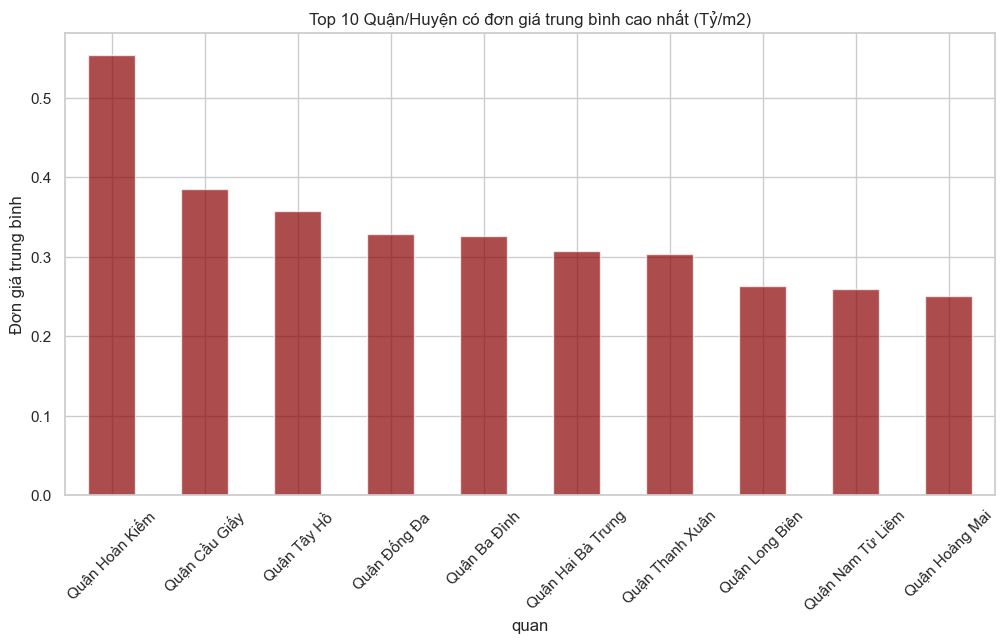

In [17]:
# Tính đơn giá trung bình trên mỗi m2 cho từng quận để so sánh
df_final['don_gia'] = df_final['gia'] / df_final['dien_tich_dat']

# Lấy Top 10 Quận có đơn giá trung bình cao nhất
top_districts = df_final.groupby('quan')['don_gia'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
top_districts.plot(kind='bar', color='darkred', alpha=0.7)
plt.title("Top 10 Quận/Huyện có đơn giá trung bình cao nhất (Tỷ/m2)")
plt.ylabel("Đơn giá trung bình")
plt.xticks(rotation=45)
plt.show()

# Xóa cột đơn giá sau khi làm EDA để tránh gây nhiễu model
df_final.drop(columns=['don_gia'], inplace=True)

### Nhận xét:

1. Đáng chú ý, toàn bộ Top 10 quận có đơn giá cao nhất trong bộ dữ liệu này đều thuộc **Hà Nội** (Cầu Giấy, Tây Hồ, Đống Đa...). Điều này giải thích tại sao ở bước phân tích trước, mặt bằng giá Hà Nội lại cao hơn TP.HCM.
2. Sự chênh lệch đơn giá giữa vị trí số 1 và số 10 là gần gấp đôi, chứng minh vị trí cụ thể (Quận/Huyện) là đặc trưng có sức ảnh hưởng lớn đến biến mục tiêu.

**Kết luận:** Việc mã hóa các biến Quận/Huyện là bắt buộc để mô hình có thể bắt kịp sự khác biệt về giá trị địa lý này.

## Xuất dữ liệu sạch và sẵn sàng huấn luyện

Dữ liệu sau khi được làm sạch, lọc bỏ Outliers và biến đổi các đặc trưng cần thiết sẽ được lưu vào file `data_final.csv`.

Tập dữ liệu này sẽ được dùng chung cho tất cả các thành viên trong nhóm để:
* Xây dựng và đánh giá 5 mô hình hồi quy khác nhau.
* So sánh các chỉ số hiệu suất như $R^2$, RMSE giữa các phương án thiết kế mô hình.
* Rút ra các thông tin chi tiết (Insights) phục vụ cho báo cáo cuối cùng.

In [18]:
base_dir = os.path.dirname(os.getcwd()) 
output_path = os.path.join(base_dir, 'data', 'preprocessed', 'data_final.csv')

os.makedirs(os.path.dirname(output_path), exist_ok=True)

df_final.to_csv(output_path, index=False, encoding='utf-8-sig')

print(f"--- XUẤT FILE THÀNH CÔNG ---")
print(f"File đã được lưu tại: {output_path}")

print("\nThông tin bộ dữ liệu cuối cùng:")
df_final.info()

print("\n5 dòng dữ liệu mẫu để kiểm tra:")
display(df_final.head())

--- XUẤT FILE THÀNH CÔNG ---
File đã được lưu tại: d:\Machine Learning\ML-Lab02-Linear_Regression_Project-Real_Estate_Price_Analysis_and_Prediction\data\preprocessed\data_final.csv

Thông tin bộ dữ liệu cuối cùng:
<class 'pandas.core.frame.DataFrame'>
Index: 9116 entries, 0 to 10017
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   tieu_de        9116 non-null   object        
 1   gia            9116 non-null   float64       
 2   dia_chi        9116 non-null   object        
 3   dien_tich_dat  9116 non-null   float64       
 4   phong_ngu      9116 non-null   int64         
 5   phong_tam      9116 non-null   int64         
 6   so_tang        9116 non-null   int64         
 7   phap_ly        9116 non-null   object        
 8   ngay_dang      9116 non-null   datetime64[ns]
 9   source_site    9116 non-null   object        
 10  gia_log        9116 non-null   float64       
 11  dien_tich_log  

,tieu_de,gia,dia_chi,dien_tich_dat,phong_ngu,phong_tam,so_tang,phap_ly,ngay_dang,source_site,gia_log,dien_tich_log,quan,thanh_pho
0,Cc bán nhà hẻm 97/ Phan Đăng Lưu Quận Phú Nhuậ...,9.00,"Phố Phan Đăng Lưu, Phường 7, Quận Phú Nhuận, H...",44.5,4,5,4,Đã có sổ,2026-03-26,batdongsan,2.302585,3.817712,Quận Phú Nhuận,TP.HCM
1,CÔ HOA CẦN BÁN NHÀ ĐƯỜNG LÊ HỒNG PHONG - Q10 -...,6.77,"Đường Lê Hồng Phong, Phường 10, Quận 10, Hồ Ch...",77.4,4,4,3,Đã có sổ,2026-03-28,batdongsan,2.050270,4.361824,Quận 10,TP.HCM
2,56M (4x15). 3 TẦNG 2PN. 5.6T - GẦN CHỢ & TRƯỜN...,5.59,"Đường Huỳnh Tấn Phát, Phường Phú Thuận, Quận 7...",56.0,3,2,3,Đã có sổ,2026-03-20,batdongsan,1.885553,4.043051,Quận 7,TP.HCM
3,"(7,8 Tỷ TL) NHÀ 3 TẦNG, 1 SẸC, GẦN SÁT MẶT TIỀ...",7.80,"Đường Bùi Thị Xuân, Phường Phạm Ngũ Lão, Quận ...",31.0,2,3,3,Đã có sổ,2026-03-29,batdongsan,2.174752,3.465736,Quận 1,TP.HCM
4,NHÀ ĐẸP TÂN BÌNH-GẦN NHÀ GA T3-KHU VỰC HIẾM NH...,14.50,"Đường Bàu Bàng, Phường 13, Quận Tân Bình, Hồ C...",97.0,5,3,2,Đã có sổ,2026-03-30,batdongsan,2.740840,4.584967,Quận Tân Bình,TP.HCM
